# Figure2_1

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure2")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functions.load_data import loadTrialsM
from functions.utils import first_trials_by_image
from functions.plotting import set_paper_theme

set_paper_theme()


In [ ]:

def get_cr(task,monkey):
    df = pd.read_excel("data_behavior/THINGS_categories.xlsx", sheet_name="Categories")
    training = df[f"{task}_is_training_category"]

    trials,files = loadTrialsM(task,monkey,verbose=True)

    # exclude the swipe-format anchor-image practice session
    trials_anchor = [tr for tr in trials if tr["trial_type"]=="main"]
    trials_stim,_ = first_trials_by_image([tr for tr in trials if tr["trial_type"]=="gen"])

    new_category = df[training == 0].category.tolist()
    old_category = df[training == 1].category.tolist()

    cr_anchor = []
    for i in range(len(old_category)):
        _trials = [tr for tr in trials_anchor if tr["img_url"].split("/")[-2]==old_category[i]]
        if _trials:
            cr_anchor.extend([trial["result"]=="CORRECT" for trial in _trials])

    cr_old = []
    for i in range(len(old_category)):
        _trials = [tr for tr in trials_stim if tr["img_url"].split("/")[-2]==old_category[i]]
        if _trials:
            cr_old.extend([trial["result"]=="CORRECT" for trial in _trials])

    cr_new = []
    for i in range(len(new_category)):
        _trials = [tr for tr in trials_stim if tr["img_url"].split("/")[-2]==new_category[i]]
        if _trials:
            cr_new.extend([trial["result"]=="CORRECT" for trial in _trials])

    p = np.mean(cr_anchor)
    se_anchor = np.sqrt(p*(1-p)/len(cr_anchor))
    p = np.mean(cr_old)
    se_old = np.sqrt(p*(1-p)/len(cr_old))
    p = np.mean(cr_new)
    se_new = np.sqrt(p*(1-p)/len(cr_new))

    return (np.mean(cr_anchor),np.mean(cr_old),np.mean(cr_new)),(se_anchor,se_old,se_new)


### Animate vs. Inanimate

In [4]:
task = "Large_animate_vs_inanimate"
cr,se =[],[]

for monkey in ["Elsa","Judy","Olaf"]:
    crs,ses = get_cr(task,monkey)
    cr.append(crs)
    se.append(ses)

cr = np.array(cr)
cr_plot = np.concatenate([cr[:,0],cr[:,1],cr[:,2]])

se = np.array(se)
se_plot = np.concatenate([se[:,0],se[:,1],se[:,2]])

data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231128_01_fmt.mat Trials Num:1119
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231129_01_fmt.mat Trials Num:856
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231130_01_fmt.mat Trials Num:909
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231201_01_fmt.mat Trials Num:951
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231202_01_fmt.mat Trials Num:927
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231204_01_fmt.mat Trials Num:1016
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231205_01_fmt.mat Trials Num:1051
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231206_01_fmt.mat Trials Num:825
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231207_01_fmt.mat Trials Num:1176
data_behavior/Monkey/Large_animate_vs_inanimate/Judy20231213_01_fmt.mat Trials Num:743
data_behavior/Monkey/Large_animate_vs_inanimate/Judy20231214_01_fmt.mat Trials Num:703
data_behavior/Monkey/Large_animate_vs_i

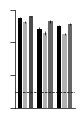

In [5]:
fig,ax = plt.subplots()
fig.set(figwidth=55/75,figheight=80/75)

half_width = 0.39
gap = 0.06
barwidth = (half_width - gap)/3*2
offset = barwidth + gap
x = [1-offset,1,1+offset,2-offset,2,2+offset,3-offset,3,3+offset]

color = [("black",1),("black",0.3),("black",0.7),("black",1),("black",0.3),("black",0.6),("black",1),("black",0.3),("black",0.6)]
ax.bar(x,cr_plot,width=barwidth,linewidth=0.2,color=color,yerr=se_plot,error_kw={"linewidth":0.5})
ax.axhline(0.5,color="black",linestyle="--",linewidth=0.5)
ax.set_xticks([])
ax.set_yticklabels([])
ax.set_ylim(0.4,1)

plt.savefig(FIGURE_OUTPUT_DIR / f"generalization_animate_vs_inanimate.pdf",transparent=True)
plt.show()

### Mammal vs. Non-mammal

In [6]:
task = "Large_mammal_vs_nonmammal"
cr,se =[],[]

for monkey in ["Elsa","Judy","Olaf"]:
    crs,ses = get_cr(task,monkey)
    cr.append(crs)
    se.append(ses)

cr = np.array(cr)
cr_plot = np.concatenate([cr[:,0],cr[:,1],cr[:,2]])

se = np.array(se)
se_plot = np.concatenate([se[:,0],se[:,1],se[:,2]])

data_behavior/Monkey/Large_mammal_vs_nonmammal/Elsa20240115_01_fmt.mat Trials Num:961
data_behavior/Monkey/Large_mammal_vs_nonmammal/Elsa20240116_01_fmt.mat Trials Num:897
data_behavior/Monkey/Large_mammal_vs_nonmammal/Elsa20240117_01_fmt.mat Trials Num:1026
data_behavior/Monkey/Large_mammal_vs_nonmammal/Elsa20240118_01_fmt.mat Trials Num:497
data_behavior/Monkey/Large_mammal_vs_nonmammal/Elsa20240119_01_fmt.mat Trials Num:805
data_behavior/Monkey/Large_mammal_vs_nonmammal/Judy20240126_01_fmt.mat Trials Num:1316
data_behavior/Monkey/Large_mammal_vs_nonmammal/Judy20240127_01_fmt.mat Trials Num:1064
data_behavior/Monkey/Large_mammal_vs_nonmammal/Judy20240129_01_fmt.mat Trials Num:1422
data_behavior/Monkey/Large_mammal_vs_nonmammal/Judy20240130_01_fmt.mat Trials Num:1243
data_behavior/Monkey/Large_mammal_vs_nonmammal/Judy20240131_01_fmt.mat Trials Num:1232
data_behavior/Monkey/Large_mammal_vs_nonmammal/Olaf20231228_01_fmt.mat Trials Num:87
data_behavior/Monkey/Large_mammal_vs_nonmammal/Ol

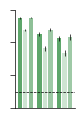

In [7]:
fig,ax = plt.subplots()
fig.set(figwidth=55/75,figheight=80/75)

half_width = 0.39
gap = 0.06
barwidth = (half_width - gap)/3*2
offset = barwidth + gap
x = [1-offset,1,1+offset,2-offset,2,2+offset,3-offset,3,3+offset]

color = [("#5EA66B",1),("#5EA66B",0.3),("#5EA66B",0.7),("#5EA66B",1),("#5EA66B",0.3),("#5EA66B",0.6),("#5EA66B",1),("#5EA66B",0.3),("#5EA66B",0.6)]
ax.bar(x,cr_plot,width=barwidth,linewidth=0.2,color=color,yerr=se_plot,error_kw={"linewidth":0.5})
ax.axhline(0.5,color="black",linestyle="--",linewidth=0.5)
ax.set_xticks([])
ax.set_yticklabels([])
ax.set_ylim(0.4,1)

plt.savefig(FIGURE_OUTPUT_DIR / f"generalization_mammal_vs_nonmammal.pdf",transparent=True)
plt.show()

### Natural vs. Artificial

In [8]:
task = "Large_natural_vs_artificial"
cr,se =[],[]

for monkey in ["Elsa","Judy","Olaf"]:
    crs,ses = get_cr(task,monkey)
    cr.append(crs)
    se.append(ses)

cr = np.array(cr)
cr_plot = np.concatenate([cr[:,0],cr[:,1],cr[:,2]])

se = np.array(se)
se_plot = np.concatenate([se[:,0],se[:,1],se[:,2]])

data_behavior/Monkey/Large_natural_vs_artificial/Elsa20231230_01_fmt.mat Trials Num:697
data_behavior/Monkey/Large_natural_vs_artificial/Elsa20240102_01_fmt.mat Trials Num:1047
data_behavior/Monkey/Large_natural_vs_artificial/Elsa20240103_01_fmt.mat Trials Num:935
data_behavior/Monkey/Large_natural_vs_artificial/Elsa20240104_01_fmt.mat Trials Num:733
data_behavior/Monkey/Large_natural_vs_artificial/Elsa20240105_01_fmt.mat Trials Num:717
data_behavior/Monkey/Large_natural_vs_artificial/Elsa20240106_01_fmt.mat Trials Num:786
data_behavior/Monkey/Large_natural_vs_artificial/Judy20240108_01_fmt.mat Trials Num:475
data_behavior/Monkey/Large_natural_vs_artificial/Judy20240109_01_fmt.mat Trials Num:889
data_behavior/Monkey/Large_natural_vs_artificial/Judy20240110_01_fmt.mat Trials Num:508
data_behavior/Monkey/Large_natural_vs_artificial/Judy20240111_01_fmt.mat Trials Num:801
data_behavior/Monkey/Large_natural_vs_artificial/Judy20240112_01_fmt.mat Trials Num:678
data_behavior/Monkey/Large_natu

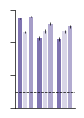

In [9]:
fig,ax = plt.subplots()
fig.set(figwidth=55/75,figheight=80/75)

half_width = 0.39
gap = 0.06
barwidth = (half_width - gap)/3*2
offset = barwidth + gap
x = [1-offset,1,1+offset,2-offset,2,2+offset,3-offset,3,3+offset]

color = [("#8074B1",1),("#8074B1",0.3),("#8074B1",0.7),("#8074B1",1),("#8074B1",0.3),("#8074B1",0.6),("#8074B1",1),("#8074B1",0.3),("#8074B1",0.6)]
ax.bar(x,cr_plot,width=barwidth,linewidth=0.2,color=color,yerr=se_plot,error_kw={"linewidth":0.5})
ax.axhline(0.5,color="black",linestyle="--",linewidth=0.5)
ax.set_xticks([])
ax.set_yticklabels([])
ax.set_ylim(0.4,1)

plt.savefig(FIGURE_OUTPUT_DIR / f"generalization_natural_vs_artificial.pdf",transparent=True)
plt.show()